In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

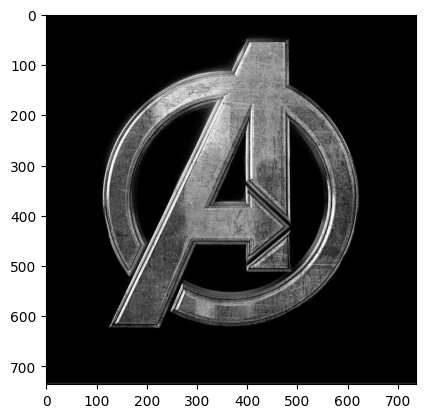

In [2]:
img = cv2.imread("doomsday.jpg", cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray')
plt.show()

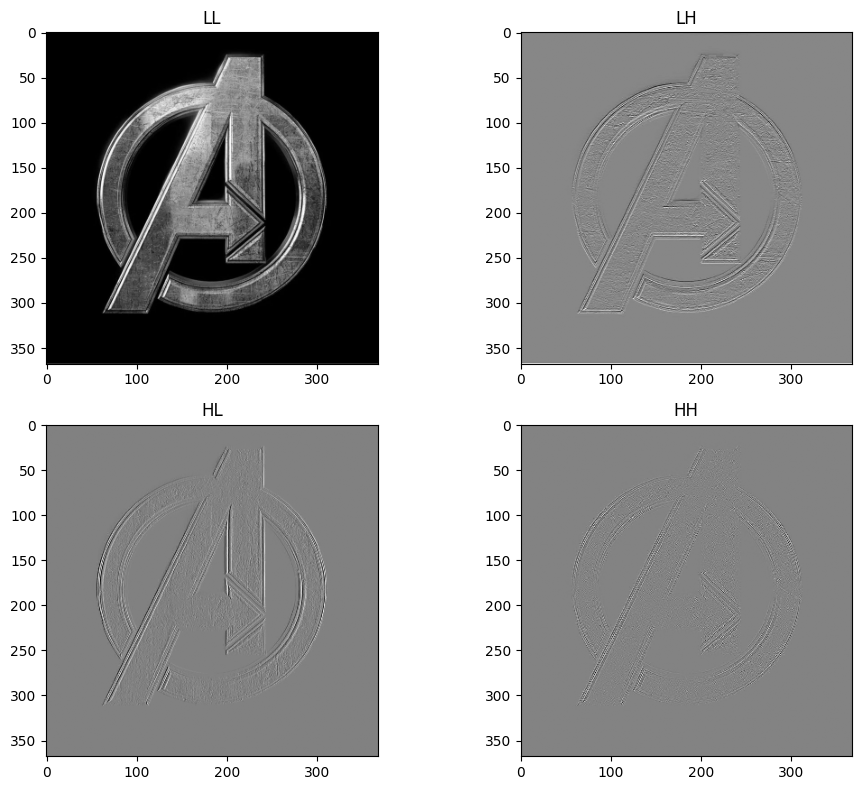

In [3]:
LPF = np.array([1/np.sqrt(2), 1/np.sqrt(2)]) 
HPF = np.array([1/np.sqrt(2), -(1/np.sqrt(2))])  

def convo_h(image, kernel):     
    ukuran_kernel = len(kernel)     
    padd = np.pad(image, [0, ukuran_kernel], mode='constant')     
    conv = np.zeros((image.shape[0], image.shape[1]))      
    for i in range(len(conv)):         
        for j in range(len(conv[i])):             
            for x in range(len(kernel)):                 
                conv[i][j] += (padd[i][j+x] * kernel[x])     
    return conv 

def convo_v(image, kernel):
    ukuran_kernel = len(kernel)
    padd = np.pad(image, [0, ukuran_kernel], mode='constant')
    conv = np.zeros((image.shape[0], image.shape[1]))
    for i in range(len(conv)):
        for j in range(len(conv[i])):
            for x in range(len(kernel)):
                conv[i][j] += (padd[i+x][j] * kernel[x])
    return conv

def downsampling_h(image):
    baris = int(image.shape[0])
    kolom = int(image.shape[1] / 2)
    downsampled = np.zeros((baris, kolom))
    for i in range(baris):
        indeks = 0
        for j in range(kolom):
            downsampled[i][j] = image[i][indeks]
            indeks += 2
    return downsampled

def downsampling_v(image):
    baris = int(image.shape[0]/2)
    kolom = int(image.shape[1])
    downsampled = np.zeros((baris, kolom))
    indeks = 0
    for i in range(baris):
        for j in range(kolom):
            downsampled[i][j] = image[indeks][j]  
        indeks += 2
    return downsampled

def normalisasi(image):
    image = (image - np.min(image)) / (np.max(image) - np.min(image)) * 255
    return image.astype(np.uint8)

def upsampling_v(image):
    baris = image.shape[0] * 2
    kolom = image.shape[1]
    upsampled = np.zeros((baris, kolom))
    for i in range(image.shape[0]):
        for j in range(kolom):
            upsampled[i*2][j] = image[i][j]
    return upsampled

def upsampling_h(image):
    baris = image.shape[0]
    kolom = image.shape[1] * 2
    upsampled = np.zeros((baris, kolom))
    for i in range(baris):
        for j in range(image.shape[1]):
            upsampled[i][j*2] = image[i][j]
    return upsampled

def wavelet(image):
    konvolusi1 = convo_h(image, LPF)
    downsampling = downsampling_h(konvolusi1)
    konvolusi2 = convo_v(downsampling, LPF)
    approximation = downsampling_v(konvolusi2)
    approximation = normalisasi(approximation)

    konvolusi1 = convo_h(image, LPF)
    downsampling = downsampling_h(konvolusi1)
    konvolusi2 = convo_v(downsampling, HPF)
    horizontal = downsampling_v(konvolusi2)
    horizontal = normalisasi(horizontal)

    konvolusi1 = convo_h(image, HPF)
    downsampling = downsampling_h(konvolusi1)
    konvolusi2 = convo_v(downsampling, LPF)
    vertikal = downsampling_v(konvolusi2)
    vertikal = normalisasi(vertikal)

    konvolusi1 = convo_h(image, HPF)
    downsampling = downsampling_h(konvolusi1)
    konvolusi2 = convo_v(downsampling, HPF)
    diagonal = downsampling_v(konvolusi2)
    diagonal = normalisasi(diagonal)

    return (approximation, horizontal, vertikal, diagonal)

approximation, horizontal, vertikal, diagonal = wavelet(img)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0,0].imshow(approximation, cmap='gray'); axes[0,0].set_title('LL')
axes[0,1].imshow(horizontal, cmap='gray');   axes[0,1].set_title('LH')
axes[1,0].imshow(vertikal, cmap='gray');     axes[1,0].set_title('HL')
axes[1,1].imshow(diagonal, cmap='gray');     axes[1,1].set_title('HH')
plt.tight_layout()
plt.show()

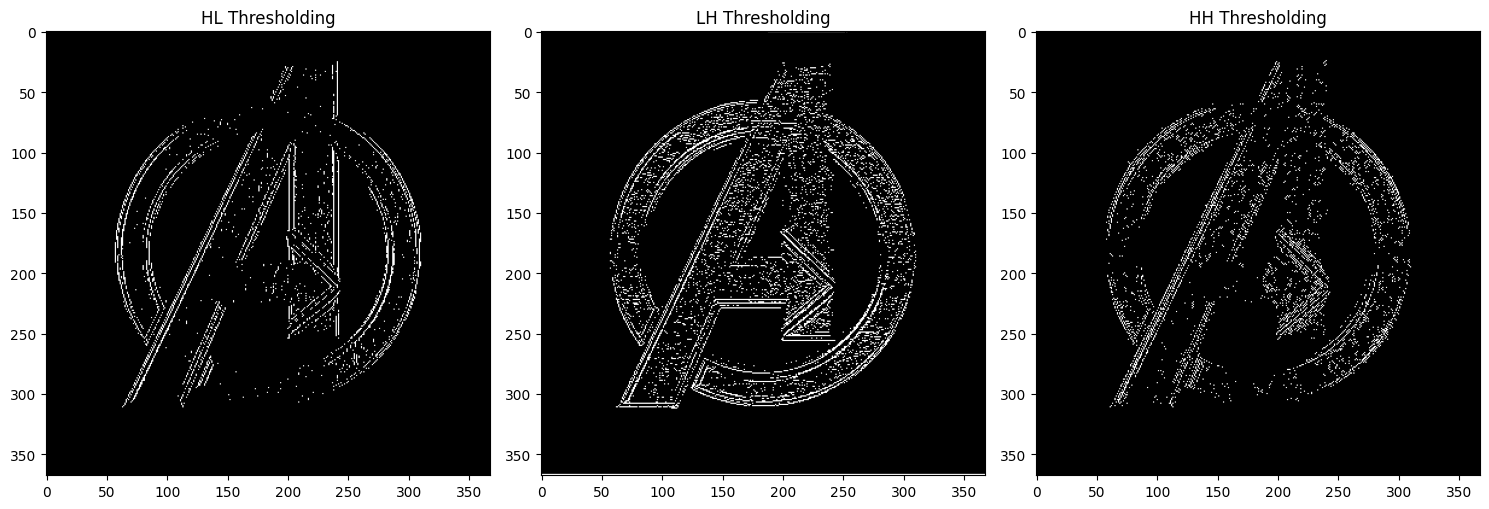

In [ ]:
threshold_val = 150

def thresholding(subband, threshold):
    rows, cols = subband.shape
    hasil = np.zeros_like(subband, dtype=np.uint8)
    for r in range(rows):
        for c in range(cols):
            val = subband[r, c]
            if val < 0:
                val = -val  
            if val >= threshold:
                hasil[r, c] = 255
    return hasil

HL_thresh = thresholding(vertikal, threshold_val)
LH_thresh = thresholding(horizontal, threshold_val)
HH_thresh = thresholding(diagonal, threshold_val)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(HL_thresh, cmap='gray'); axes[0].set_title('HL Thresholding')
axes[1].imshow(LH_thresh, cmap='gray'); axes[1].set_title('LH Thresholding')
axes[2].imshow(HH_thresh, cmap='gray'); axes[2].set_title('HH Thresholding')
plt.tight_layout()
plt.show()

HL (Horizontal Detail)
Setelah dilakukan closing, bagian tepi dan garis yang dominan secara horizontal terlihat lebih menyatu karena celah-celah kecil berhasil ditutup. Noise berupa titik-titik hitam yang memutus garis berkurang sehingga bentuk logo menjadi lebih jelas dan kontinyu.

LH (Vertical Detail)
Operasi closing membuat komponen vertikal pada logo tampak lebih padat dan utuh. Lubang-lubang kecil di dalam objek banyak yang tertutup, sehingga area putih menjadi lebih solid dan kontur vertikal lebih mudah dikenali dibandingkan sebelum proses morfologi.

HH (Diagonal Detail)
Pada subband HH yang berisi detail diagonal dan frekuensi tinggi, closing membantu menghubungkan bagian-bagian diagonal yang sebelumnya terputus akibat noise. Detail logo menjadi lebih menyatu, meskipun masih terdapat beberapa bintik noise karena karakteristik HH memang menyimpan banyak informasi tepi halus dan tekstur.

Operasi closing berhasil mengurangi celah kecil dan menyambungkan bagian objek yang terputus pada ketiga subband. Efek paling terlihat pada LH yang menghasilkan objek paling solid, sedangkan pada HH perbaikannya tidak sebesar HL dan LH karena subband ini didominasi detail frekuensi tinggi yang lebih rentan terhadap noise.

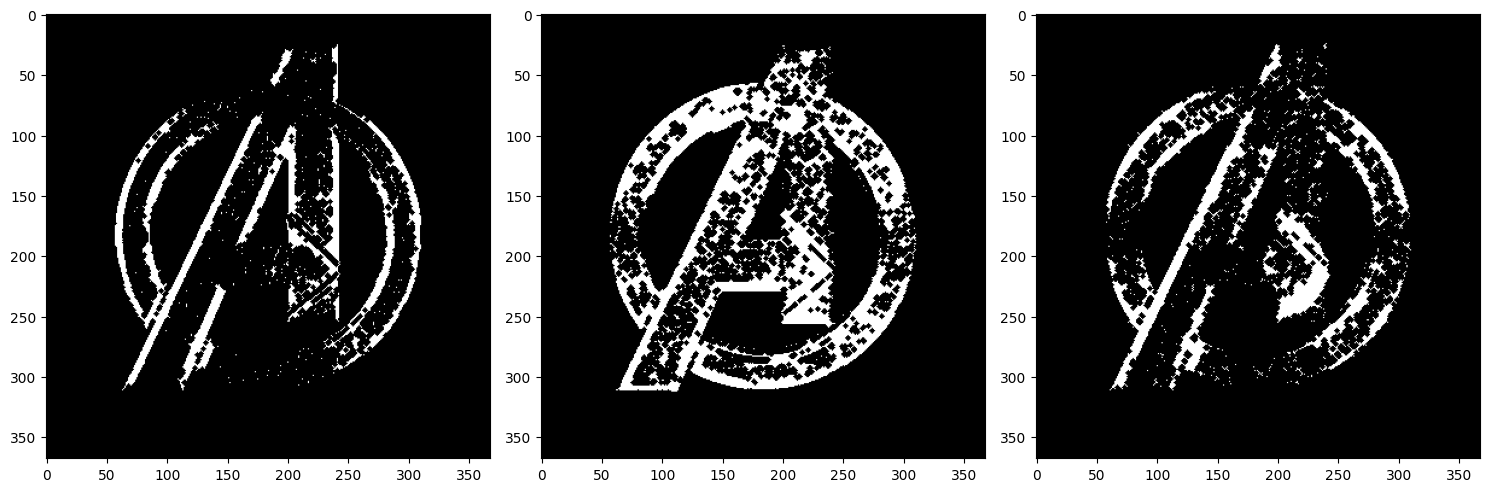

In [5]:
def dilasi(image,kernel): 
    height, width = image.shape 
    k_height, k_width = kernel.shape 
    center = k_height//2 
    hasil = np.zeros((height, width)) 
    for i in range(center, height-center): 
        for j in range(center, width-center): 
            if image[i,j] == 255: 
                for k in range(k_height): 
                    for l in range(k_width): 
                        if kernel[k,l] == 1: 
                            hasil[i+k-center,j+l-center] =255 
            else: 
                if hasil[i,j] !=255: 
                    hasil[i,j] = 0  
    return hasil

def erosi(image, kernel): 
    h, w = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2

    hasil = np.zeros((h, w), dtype=np.uint8)

    for i in range(center, h - center): 
        for j in range(center, w - center): 

            cocok = True 

            for k in range(k_height): 
                for l in range(k_width): 

                    if kernel[k, l] == 1 and image[i + k - center, j + l - center] == 0: 
                        cocok = False 
                        break 

                if not cocok: 
                    break 

            if cocok: 
                hasil[i, j] = 255 

    return hasil

def closing(image, kernel):
    return erosi(dilasi(image, kernel), kernel)

kernel5 = np.array([[0, 0, 1, 0, 0],
                    [0, 1, 1, 1, 0],
                    [1, 1, 1, 1, 1],
                    [0, 1, 1, 1, 0],
                    [0, 0, 1, 0, 0]])

HL_closing = closing(HL_thresh, kernel5)
LH_closing = closing(LH_thresh, kernel5)
HH_closing = closing(HH_thresh, kernel5)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(HL_closing, cmap='gray')
axes[1].imshow(LH_closing, cmap='gray')
axes[2].imshow(HH_closing, cmap='gray')
plt.tight_layout()
plt.show()

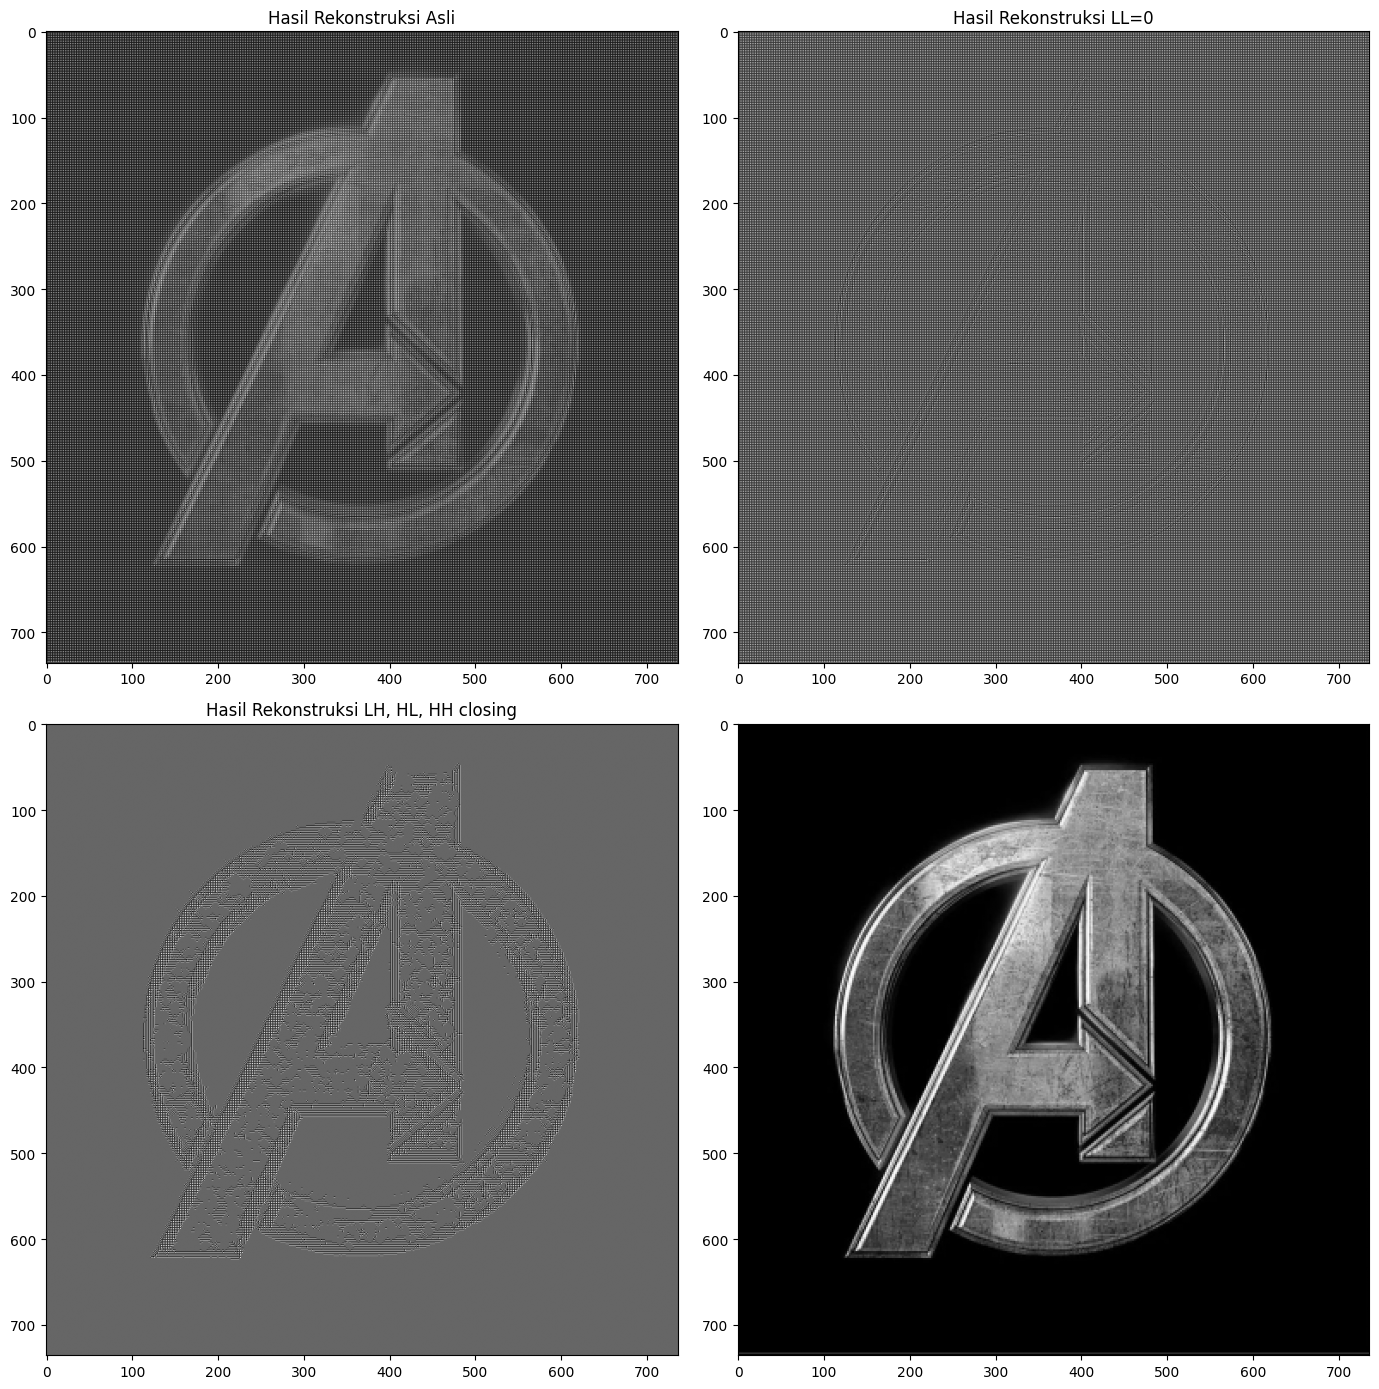

In [6]:
def rekonstruksi(LL, LH, HL, HH):
    
    upsampling = upsampling_v(LL)
    konvolusiL = convo_v(upsampling, LPF)

    upsampling = upsampling_v(LH)
    konvolusiH = convo_v(upsampling, HPF)

    upsampling = upsampling_h(konvolusiL + konvolusiH)
    konvolusiL2 = convo_h(upsampling, LPF)

    upsampling = upsampling_v(HL)
    konvolusiL = convo_v(upsampling, LPF)

    upsampling = upsampling_v(HH)
    konvolusiH = convo_v(upsampling, HPF)

    upsampling = upsampling_h(konvolusiL + konvolusiH)
    konvolusiH2 = convo_h(upsampling, HPF)

    hasil = konvolusiL2 + konvolusiH2
    return hasil

hasil_rekonstruksi = rekonstruksi(approximation, horizontal, vertikal, diagonal)

LL_nol = np.zeros_like(approximation, dtype=np.float64)
LL0 = rekonstruksi(LL_nol, horizontal, vertikal, diagonal)

LH_c = LH_closing.astype(np.float64)
HL_c = HL_closing.astype(np.float64)
HH_c = HH_closing.astype(np.float64)
rekonstruksi_closing = rekonstruksi(LL_nol, LH_c, HL_c, HH_c)

LL= rekonstruksi(approximation, np.zeros_like(horizontal), np.zeros_like(vertikal), np.zeros_like(diagonal))

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes[0,0].imshow(hasil_rekonstruksi, cmap='gray')
axes[0,0].set_title('Hasil Rekonstruksi Asli')
axes[0,1].imshow(LL0, cmap='gray')
axes[0,1].set_title('Hasil Rekonstruksi LL=0')
axes[1,0].imshow(rekonstruksi_closing, cmap='gray')
axes[1,0].set_title('Hasil Rekonstruksi LH, HL, HH closing')
axes[1,1].imshow(LL, cmap='gray')
plt.tight_layout()
plt.show()